# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [3]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [4]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "214138"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v19bb2105
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,2.268341,-1.448351,1.634137,-0.142958,-0.477618,1.437361,-0.268566,0.434846,0.420024,-0.109882,-0.532641,0.604899,9.023845
1,37.694163,1.930971,-1.929255,-0.096816,-0.328423,2.547800,-0.333832,3.811705,0.791566,-1.204634,2.214540,2.234137,29.859980
2,84.566373,-0.207075,-1.038080,-1.176303,0.400092,0.384798,0.479772,7.473275,0.384675,-1.032417,-1.279066,-2.819659,20.830171
3,24.252037,0.547056,-1.176245,1.329721,0.191654,0.611459,0.490989,1.112821,1.459613,-0.814970,0.820708,-2.263787,10.085219
4,90.347338,1.742187,0.550536,2.077443,-0.024232,2.053232,-0.497413,0.479147,3.925798,-0.167077,1.161339,1.989348,24.109431


In [5]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,50.225436,28.630068,0.455557,26.110879,49.886589,74.810546,99.808744
x2,800.0,-0.042215,1.156987,-1.993852,-1.075045,-0.021272,0.866576,1.999088
x3,800.0,0.020078,1.114437,-1.999776,-0.884220,0.033423,0.930271,1.987143
x4,800.0,0.035057,0.963398,-2.915605,-0.600920,0.048771,0.666381,3.254166
x5,800.0,0.021860,0.288281,-0.499323,-0.212010,0.010001,0.282968,0.499309
x6,800.0,2.013283,1.137301,0.018516,1.041866,1.993152,2.990263,3.998113
x7,800.0,0.002290,0.292888,-0.499755,-0.257887,0.008323,0.266356,0.498683
x8,800.0,1.793037,2.568256,0.058771,0.504250,1.014586,2.031611,26.819536
x9,800.0,1.606743,1.925338,0.045530,0.483570,0.986754,2.055395,23.098297
x10,800.0,0.010895,0.983557,-2.713639,-0.626787,0.022295,0.629778,2.977323


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 117.31
R² del baseline en validación : 0.443

Desviación estándar de y: 14.55


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

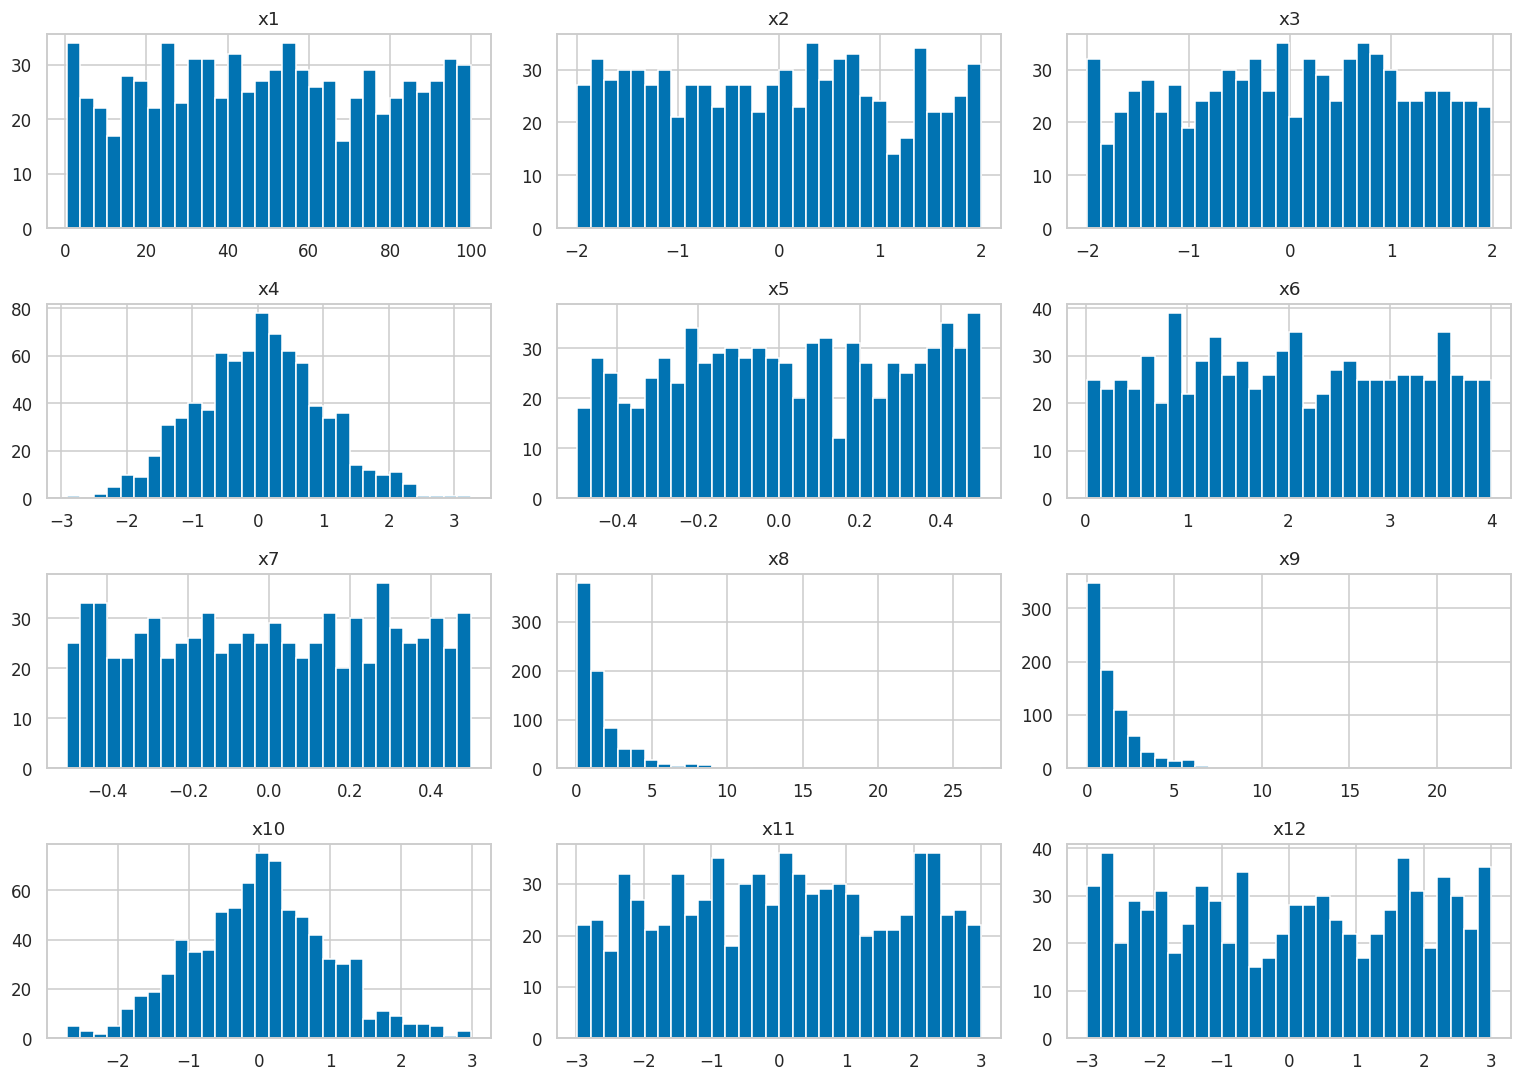

In [7]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.
train[VARIABLES].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

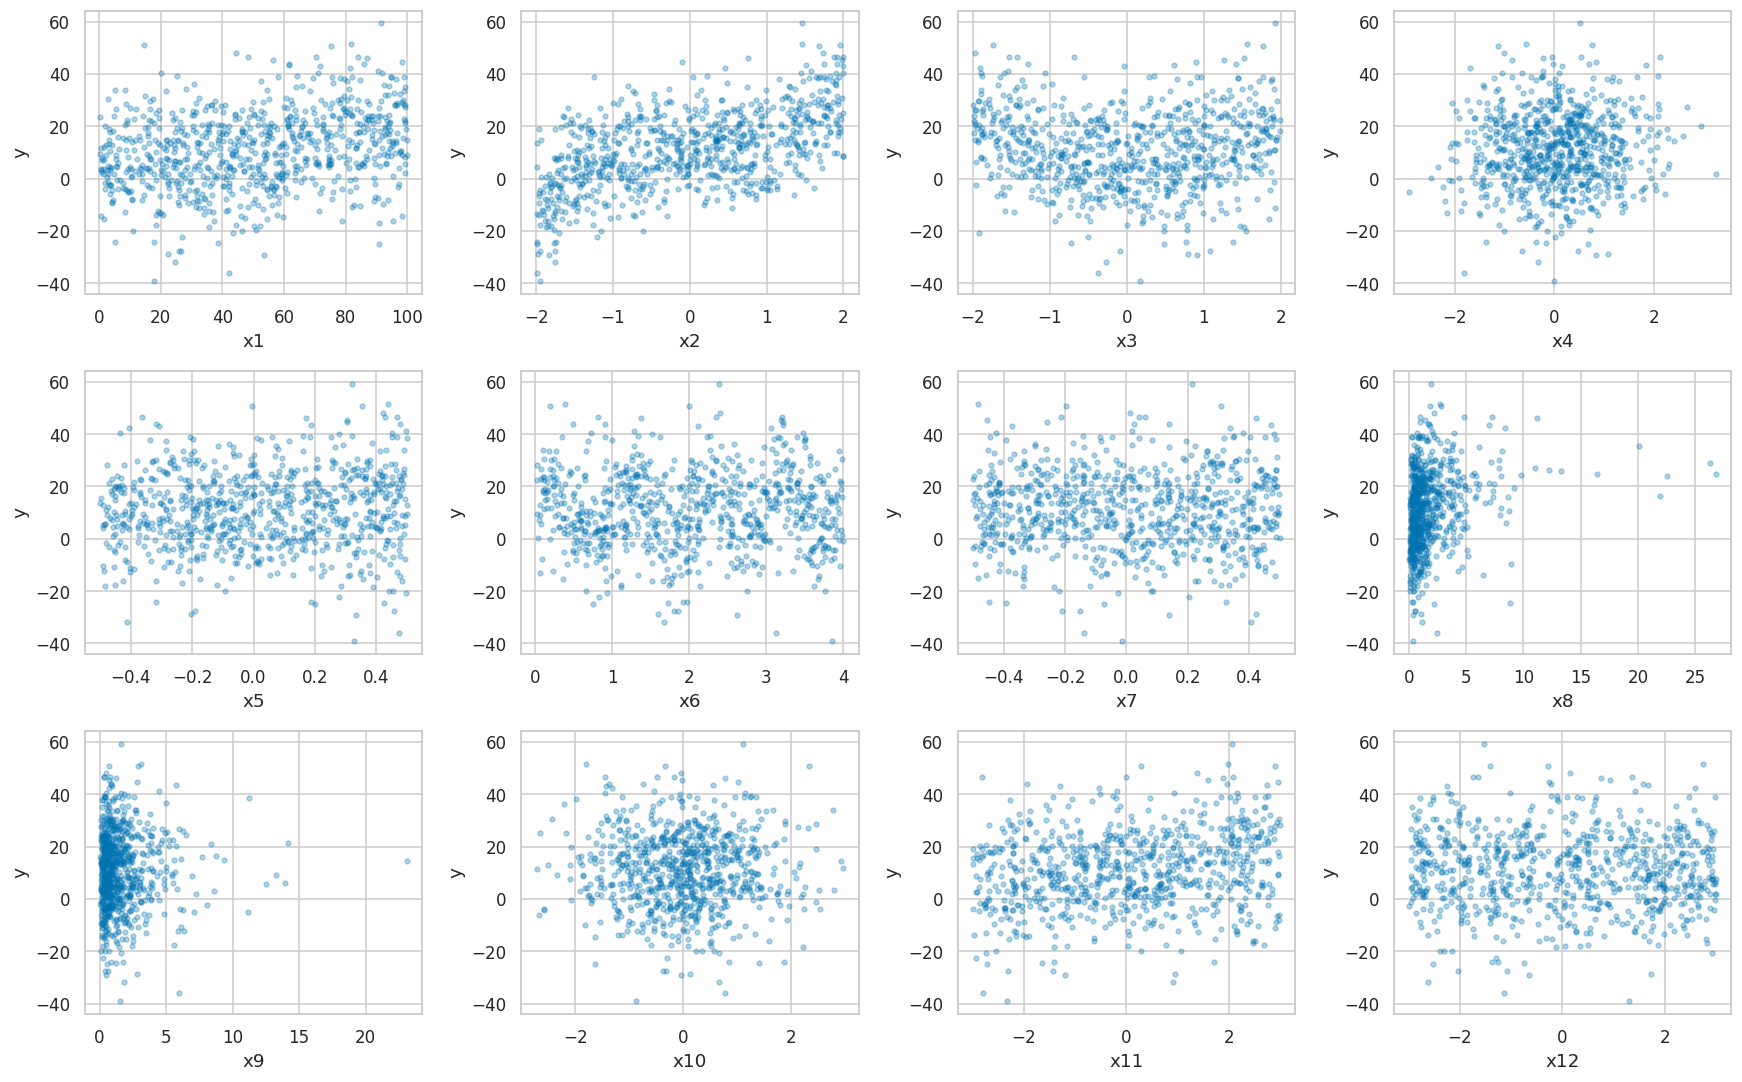

In [8]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(VARIABLES):
    axes[i].scatter(train[var], train["y"], alpha=0.3, s=10)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

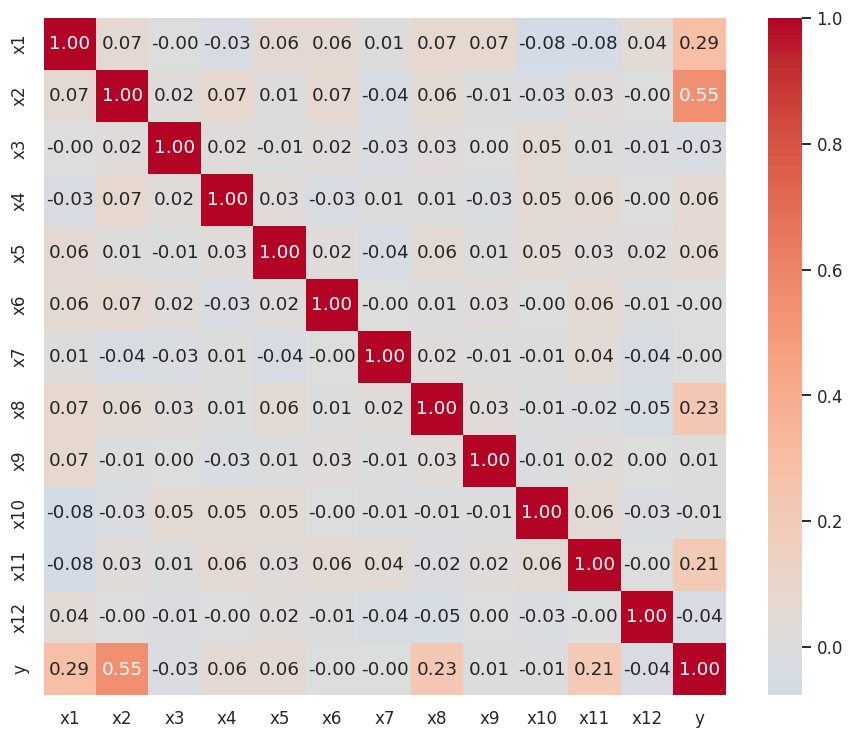

In [9]:
# TODO: matriz de correlación entre las 12 variables y `y`.
corr = train[VARIABLES + ["y"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` |relación positiva con y | matriz y scatter | mas o menos |
| `x2` | relacion fuerte | matriz y scatter | segura |
| `x3` | no veo como relación | matriz y scatter | casi si segura |
| `x4` | distribución en forma de campana | histograma | mas o menos |
| `x5` | no parece haber relación | scatter| casi si segura|
| `x6` | no se ve mucha relación| matriz| poco |
| `x7` | tampoco se ve mucha relación | matriz y scatter | casi si segura |
| `x8` | distrubución sesgada a la izquierda | histograma | muy segura hay que transformar|
| `x9` | igual sesgada que x8 | histograma | mas o menos pero diria que tambien trasnformación |
| `x10` | campana| histograma| casi si segura|
| `x11` | veo algo de relacion| matriz| mas o menos|
| `x12` | no veo mucha relacion| matriz| casi si segura|

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [10]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 117.31


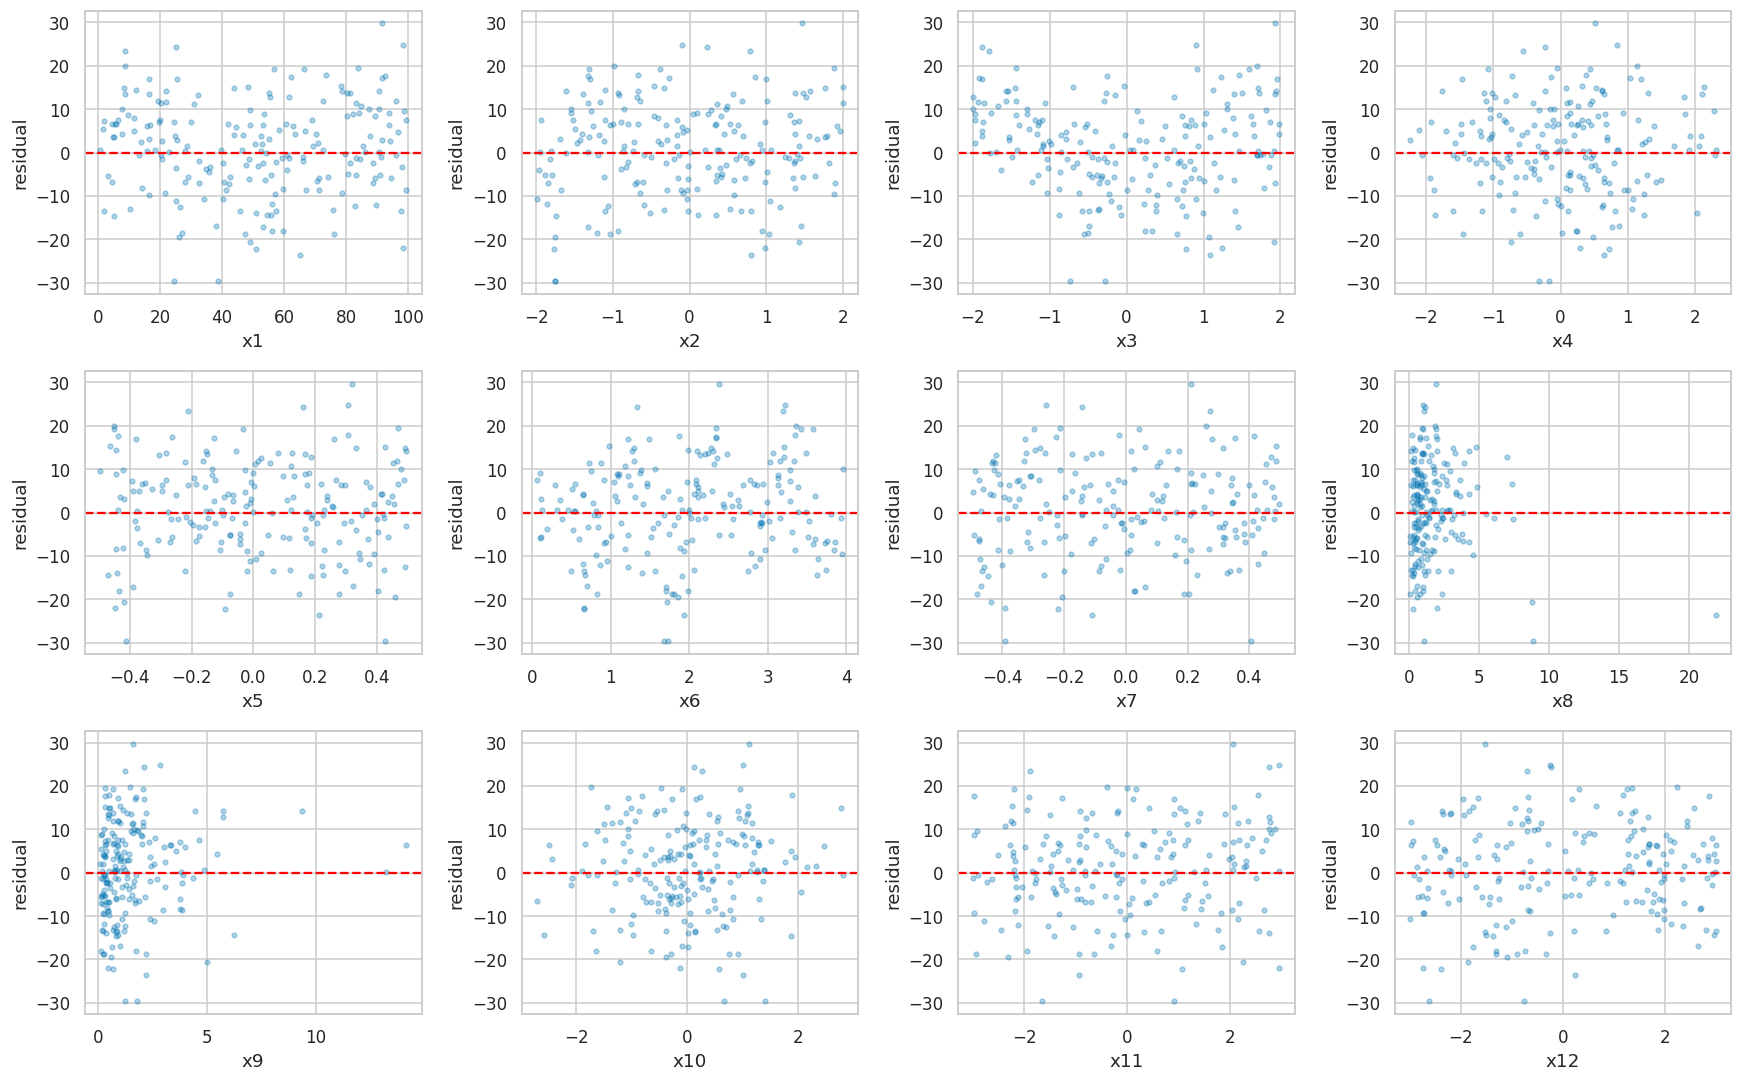

In [11]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(VARIABLES):
    axes[i].scatter(X_val[var], residuales, alpha=0.3, s=10)
    axes[i].axhline(0, color="red", linestyle="--")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("residual")

plt.tight_layout()
plt.show()

In [12]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

modelo, mse, residuales, _ = ajusta({"x3_cuadrada": lambda d: d["x3"]**2})
print(f"MSE: {mse:.2f}")

MSE: 98.62


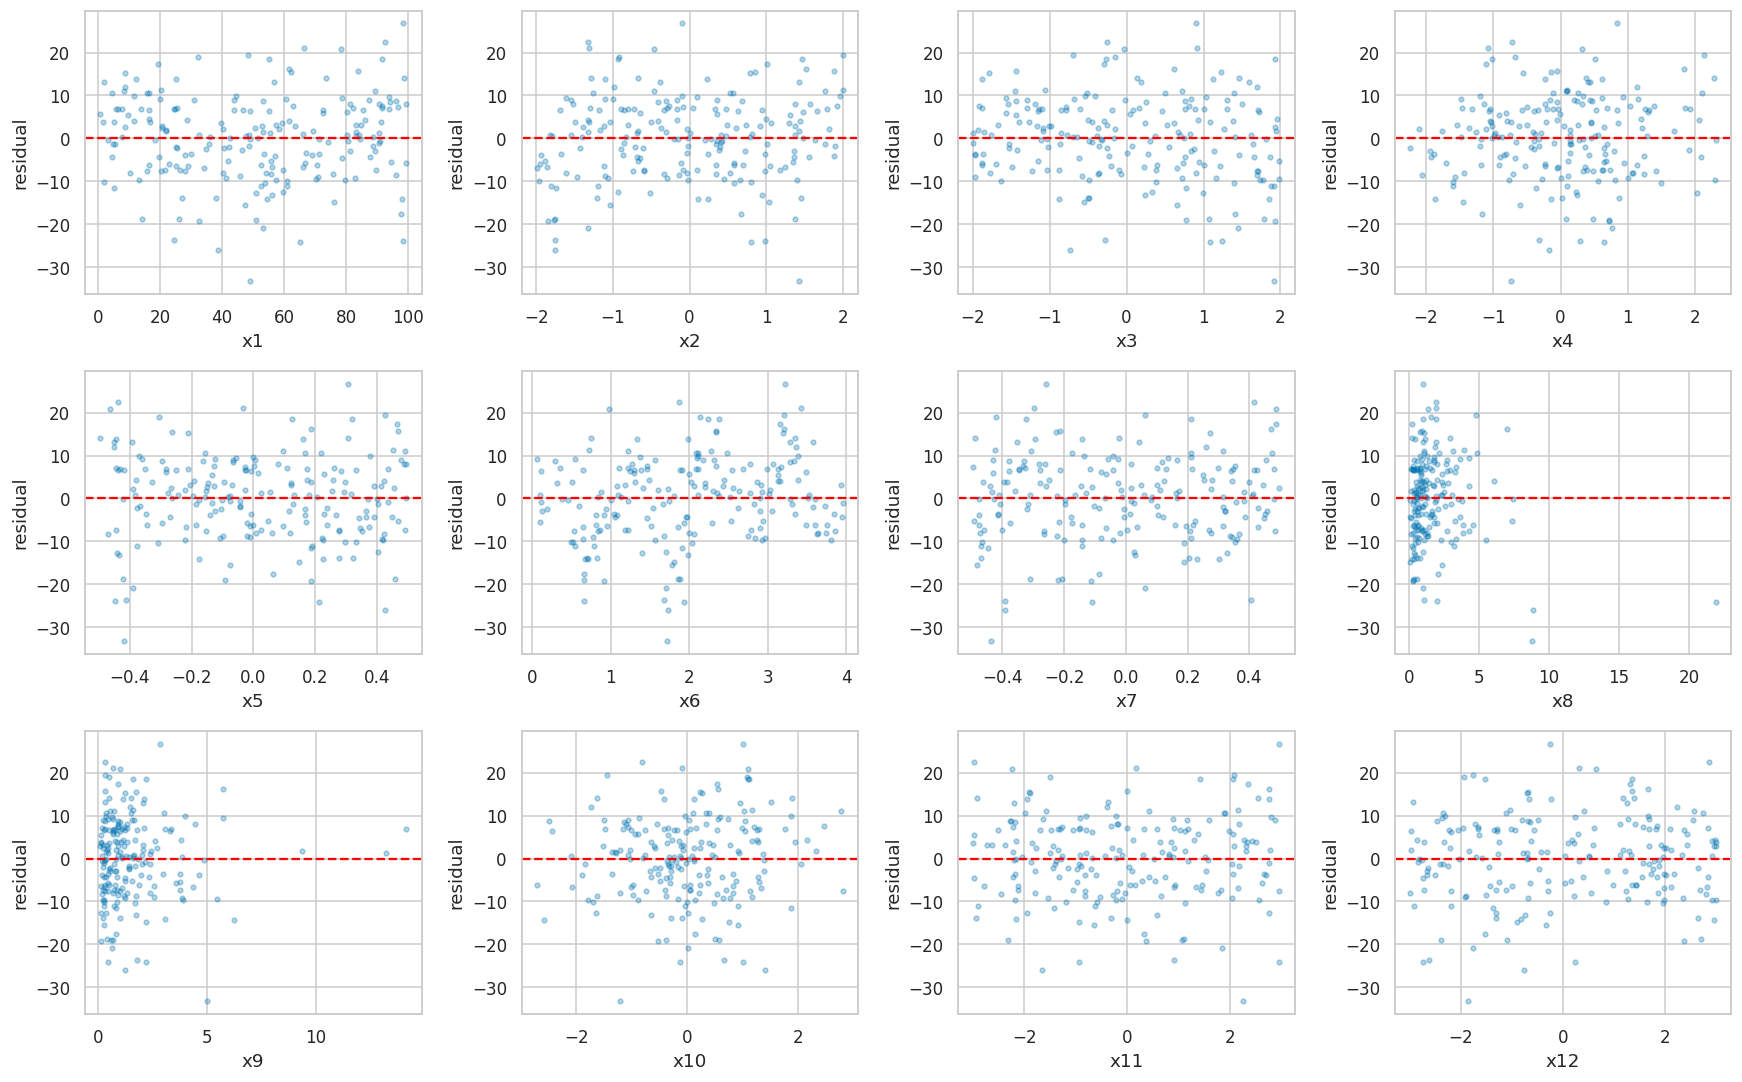

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(VARIABLES):
    axes[i].scatter(X_val[var], residuales, alpha=0.3, s=10)
    axes[i].axhline(0, color="red", linestyle="--")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("residual")

plt.tight_layout()
plt.show()

In [14]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.
modelo, mse, residuales, _ = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"])
})
print(f"MSE: {mse:.2f}")


MSE: 93.31


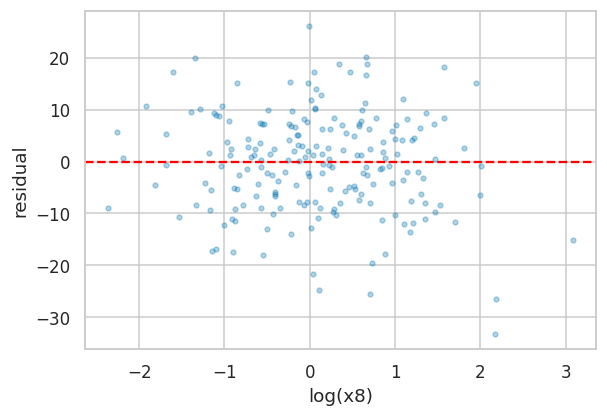

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(np.log(X_val["x8"]), residuales, alpha=0.3, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("log(x8)")
plt.ylabel("residual")
plt.show()

In [16]:
modelo, mse, residuales, _ = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x9_log": lambda d: np.log(d["x9"])
})
print(f"MSE: {mse:.2f}")
#no vemos un cambio significativo en MSE

MSE: 93.26


In [17]:
modelo, mse, residuales, _ = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"])
})
print(f"MSE: {mse:.2f}")

MSE: 88.39


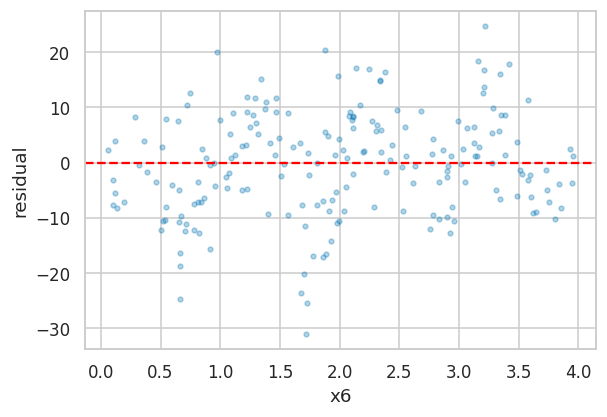

In [18]:
plt.figure(figsize=(6, 4))
plt.scatter(X_val["x6"], residuales, alpha=0.3, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x6")
plt.ylabel("residual")
plt.show()

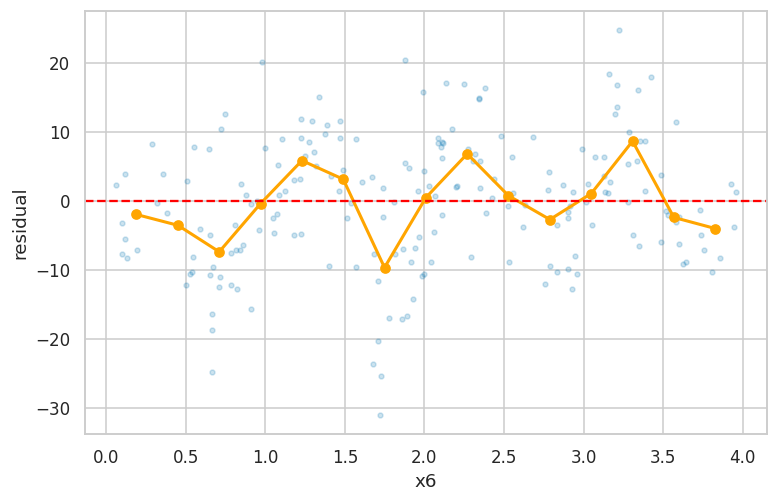

In [19]:
bins = pd.cut(X_val["x6"], bins=15)
promedio_por_bin = pd.Series(residuales).groupby(bins, observed=True).mean()

plt.figure(figsize=(8, 5))
plt.scatter(X_val["x6"], residuales, alpha=0.2, s=10)
plt.plot(
    [interval.mid for interval in promedio_por_bin.index],
    promedio_por_bin.values,
    color="orange", linewidth=2, marker="o"
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x6")
plt.ylabel("residual")
plt.show()
#codigo de ia porque intente investigar maneras de ver un cambio en la grafica ya que no lo encontraba pero me quedo con la alta disminucion en el mse tras mi cambio

In [20]:
modelo, mse, residuales, _ = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x2_cuadrada": lambda d: d["x2"]**2
})
print(f"MSE: {mse:.2f}")

MSE: 88.11


In [21]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"])
})
print(f"MSE final de validación: {mse:.2f}")

MSE final de validación: 88.39


---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [22]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x2": lambda d: d["x1"] * d["x2"]
})
print(f"MSE: {mse:.2f}")

MSE: 90.28


In [23]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x2_x8": lambda d: d["x2"] * d["x8"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.13


In [24]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x8_x9": lambda d: d["x8"] * d["x9"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.41


In [25]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x2_x11": lambda d: d["x2"] * d["x11"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.33


In [26]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x3_x6": lambda d: d["x3"] * d["x6"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.45


In [27]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x2_x3": lambda d: d["x2"] * d["x3"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.67


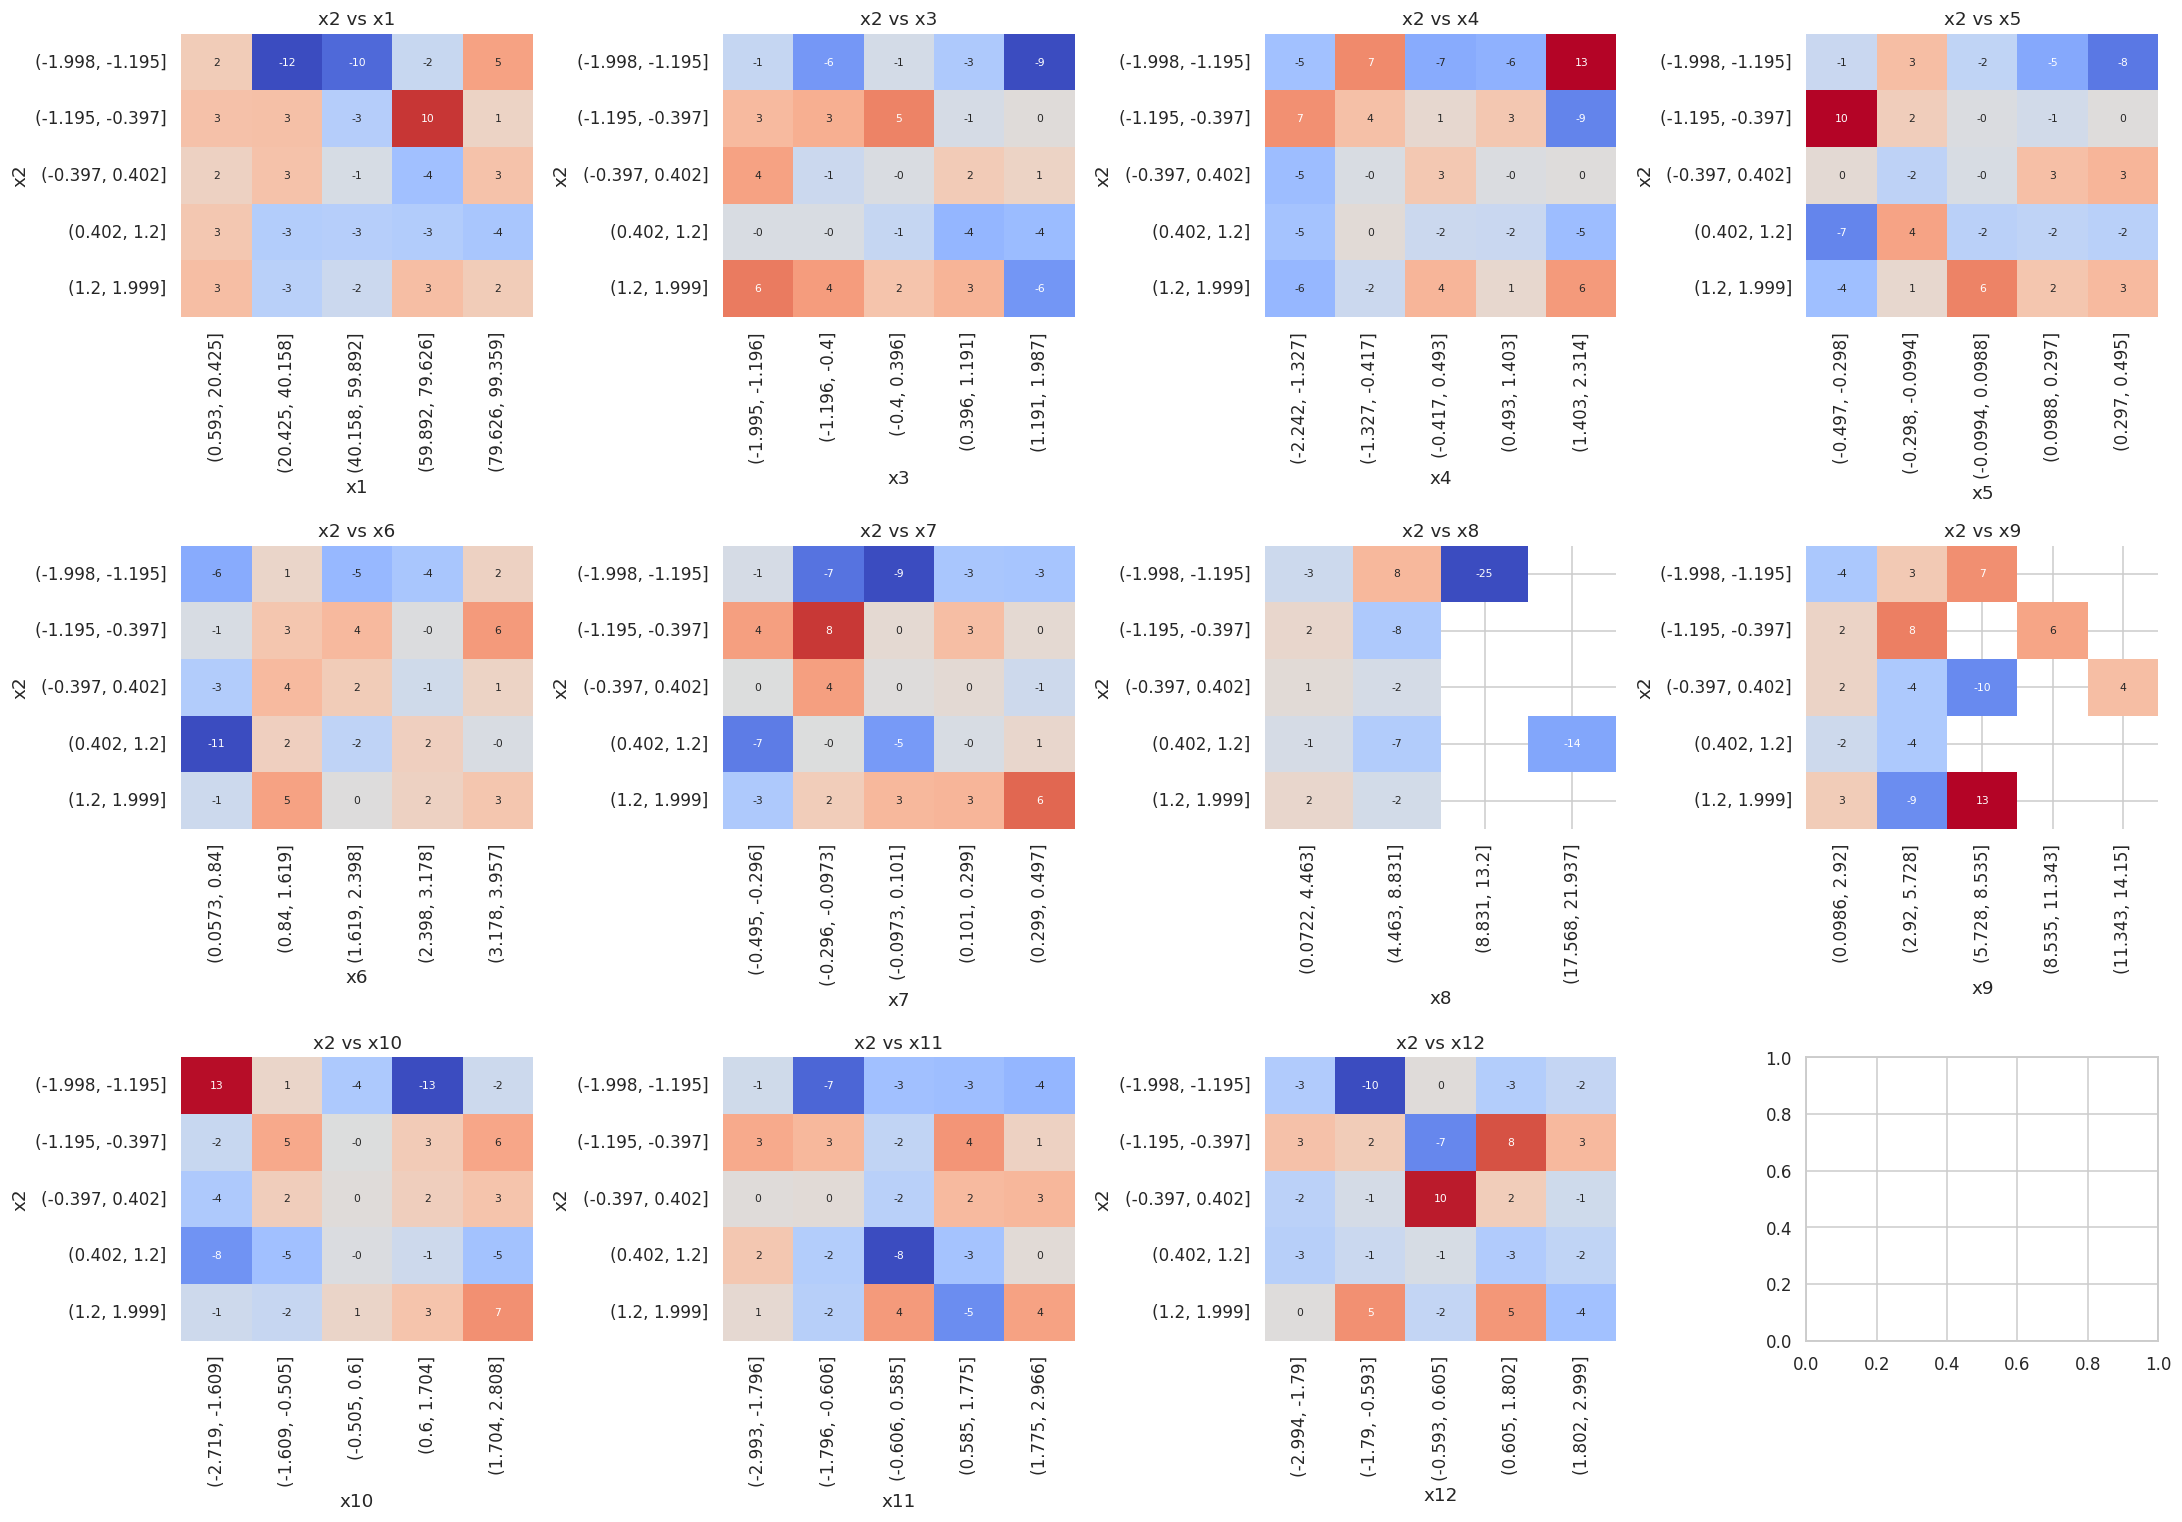

In [28]:
otras_variables = [v for v in VARIABLES if v != "x2"]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

bins_x2 = pd.cut(X_val["x2"], bins=5)

for i, var in enumerate(otras_variables):
    bins_var = pd.cut(X_val[var], bins=5)
    tabla = pd.DataFrame({
        "residual": residuales,
        "x2": bins_x2,
        "var": bins_var
    }).groupby(["x2", "var"], observed=True)["residual"].mean().unstack()
    
    sns.heatmap(tabla, annot=True, fmt=".0f", cmap="coolwarm", center=0, 
                ax=axes[i], cbar=False, annot_kws={"size": 7})
    axes[i].set_title(f"x2 vs {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("x2")

plt.tight_layout()
plt.show()

In [29]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x2_x10": lambda d: d["x2"] * d["x10"]
})
print(f"MSE: {mse:.2f}")

MSE: 90.30


In [30]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"]
})
print(f"MSE: {mse:.2f}")

MSE: 87.96


In [31]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x11"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.29


In [32]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x3"]
})
print(f"MSE: {mse:.2f}")

MSE: 89.05


In [33]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x6"]
})
print(f"MSE: {mse:.2f}")

MSE: 88.95


In [34]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"]
})
print(f"MSE: {mse:.2f}")

MSE: 87.96


In [35]:
from sklearn.model_selection import cross_val_score

def construye_con_x1x8(df):
    salida = df[VARIABLES].copy()
    salida["x3_cuadrada"] = df["x3"]**2
    salida["x8_log"] = np.log(df["x8"])
    salida["x6_sin"] = np.sin(df["x6"])
    salida["x6_cos"] = np.cos(df["x6"])
    salida["x1_x8"] = df["x1"] * df["x8"]
    return salida

X_completo = construye_con_x1x8(train)
y_completo = train["y"]

scores = cross_val_score(
    LinearRegression(), X_completo, y_completo,
    cv=5, scoring="neg_mean_squared_error"
)
mse_cv = -scores.mean()
print(f"MSE promedio (5 particiones): {mse_cv:.2f}")
print(f"MSEs individuales: {[f'{-s:.2f}' for s in scores]}")

MSE promedio (5 particiones): 86.13
MSEs individuales: ['85.34', '89.39', '86.36', '89.29', '80.28']


In [36]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"],
    "x2_cubo": lambda d: d["x2"]**3
})
print(f"MSE: {mse:.2f}")

MSE: 79.79


In [37]:
from sklearn.model_selection import cross_val_score

def construye_final_prueba(df):
    salida = df[VARIABLES].copy()
    salida["x3_cuadrada"] = df["x3"]**2
    salida["x8_log"] = np.log(df["x8"])
    salida["x6_sin"] = np.sin(df["x6"])
    salida["x6_cos"] = np.cos(df["x6"])
    salida["x1_x8"] = df["x1"] * df["x8"]
    salida["x2_cubo"] = df["x2"]**3
    return salida

X_completo = construye_final_prueba(train)
y_completo = train["y"]

scores = cross_val_score(
    LinearRegression(), X_completo, y_completo,
    cv=5, scoring="neg_mean_squared_error"
)
mse_cv = -scores.mean()
print(f"MSE promedio (5 particiones): {mse_cv:.2f}")
print(f"MSEs individuales: {[f'{-s:.2f}' for s in scores]}")

MSE promedio (5 particiones): 75.85
MSEs individuales: ['75.33', '76.96', '77.83', '73.54', '75.60']


In [38]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"],
    "x2_cubo": lambda d: d["x2"]**3,
    "x1_cuadrada": lambda d: d["x1"]**2
})
print(f"MSE: {mse:.2f}")

MSE: 77.42


In [39]:
from sklearn.model_selection import cross_val_score

def construye_final_prueba(df):
    salida = df[VARIABLES].copy()
    salida["x3_cuadrada"] = df["x3"]**2
    salida["x8_log"] = np.log(df["x8"])
    salida["x6_sin"] = np.sin(df["x6"])
    salida["x6_cos"] = np.cos(df["x6"])
    salida["x1_x8"] = df["x1"] * df["x8"]
    salida["x2_cubo"] = df["x2"]**3
    salida["x1_cuadrada"] = df["x1"]**2
    return salida

X_completo = construye_final_prueba(train)
y_completo = train["y"]

scores = cross_val_score(
    LinearRegression(), X_completo, y_completo,
    cv=5, scoring="neg_mean_squared_error"
)
mse_cv = -scores.mean()
print(f"MSE promedio (5 particiones): {mse_cv:.2f}")
print(f"MSEs individuales: {[f'{-s:.2f}' for s in scores]}")

MSE promedio (5 particiones): 74.77
MSEs individuales: ['73.39', '76.64', '76.44', '72.31', '75.08']


In [40]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"],
    "x2_cubo": lambda d: d["x2"]**3,
    "x1_cuadrada": lambda d: d["x1"]**2,
    "x5_x11": lambda d: d["x5"] * d["x11"],
})
print(f"MSE: {mse:.2f}")

MSE: 50.34


In [41]:
from sklearn.model_selection import cross_val_score

def construye_final_prueba(df):
    salida = df[VARIABLES].copy()
    salida["x3_cuadrada"] = df["x3"]**2
    salida["x8_log"] = np.log(df["x8"])
    salida["x6_sin"] = np.sin(df["x6"])
    salida["x6_cos"] = np.cos(df["x6"])
    salida["x1_x8"] = df["x1"] * df["x8"]
    salida["x2_cubo"] = df["x2"]**3
    salida["x1_cuadrada"] = df["x1"]**2
    salida["x5_x11"] = df["x5"] * df["x11"]
    return salida

X_completo = construye_final_prueba(train)
y_completo = train["y"]

scores = cross_val_score(
    LinearRegression(), X_completo, y_completo,
    cv=5, scoring="neg_mean_squared_error"
)
mse_cv = -scores.mean()
print(f"MSE promedio (5 particiones): {mse_cv:.2f}")
print(f"MSEs individuales: {[f'{-s:.2f}' for s in scores]}")

MSE promedio (5 particiones): 48.20
MSEs individuales: ['49.32', '44.84', '45.54', '52.58', '48.73']


In [42]:
modelo, mse, residuales, construye = ajusta({
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"],
    "x2_cubo": lambda d: d["x2"]**3,
    "x1_cuadrada": lambda d: d["x1"]**2,
    "x5_x11": lambda d: d["x5"] * d["x11"],
    "x11_cubo": lambda d: d["x11"]**3,
})
print(f"MSE: {mse:.2f}")

MSE: 50.11


# TODO: agreguen lo que hayan encontrado y midan.

---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [43]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, random_state=SEMILLA, max_iter=10000)
)

pipeline.fit(X_train, y_train)
pred_val = pipeline.predict(X_val)
mse_fuerza_bruta = mean_squared_error(y_val, pred_val)

columnas_distintas_de_cero = (pipeline.named_steps["lassocv"].coef_ != 0).sum()

print(f"MSE de validación (fuerza bruta): {mse_fuerza_bruta:.2f}")
print(f"Columnas distintas de cero: {columnas_distintas_de_cero}")

MSE de validación (fuerza bruta): 58.08
Columnas distintas de cero: 43


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

*(Su respuesta aquí)*

CALIFICACIÓN 1
1. Lasso con 58.08 contra mi modelo en 86.88 ganó la fuerza bruta.
2. No le ganó
3. Principalmente mi modelo solo caputo una interacción de las 66 posibles, la elegí por la conexión que ya veía en la matriz y por distintas pruebas que realicé hasta encontrar esa sobre mis hipótesis siendo el mejor resultado. La fuerza bruto probó todas las combinaciones posibles hasta grado 3 y encontro las 43 columnas mencionadas.
4. Creo que si solo se tuviera 80 observaciones sería más pesado distinguir el ruido, principalmente ya que con tantas columnas el modelo comenzaría a memorizar y podría confundiar la casualidad con causalidad sin realmente aprender debido a la falta de evidencia estadística para aprender a diferenciar los coeficientes genuinamente diferentes a cero.
CALIFICACIÓN 2
1. Mi modelo ganó con un 48.2 vs la fuerza bruta con 58.05 en su MSE promedio.
2. Adjunte a mi modelo los dos coeficientes más grandes que daba el modelo Lasso y Polynomial Feautures, ya que de esa manera priorizaba bajar sin caer en un sobreajuste, mi hipoetisis era justo que no es como que pudiera emplear todo pero sí saber elegir y ver el efecto, afortunadamente en esta ocasión calló increíble ya que haciendo el cross validation vi que no solo era una casualidad y que incluso en la grafica de residuales tenia sentido por ejemplo para x2^3 que no era una transformación que detectaba al inicio, y aunque la combinación de x5 y x11 no era en si evidente, el alto coeficiente fue una buena señal.
3. Gané
4. En este caso que hubo influencia de la fuerza bruta, es probable que con menos datos ni siqueira algo como Lasso lo hubiera detectado lo más probable es que se identificara como ruido y eso influyera en como es que cosas que ni empiricamente, ni con programas como ese puedan identificarse tan bien. Aunado a lo que respondí para la primera vez de esta pregunta.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | x3 tiene forma de "U" en sus residuales, aunque su correlación con y sea casi 0 | Residuales vs x3, tras el baseline | x3^2 | 117.31 a 98.62 | Yo |
| 2 | x8 tiene distribución muy sesgada, necesita logaritmo | Histograma de x8; residuales en forma de embudo | log(x8) | 98.62 a 93.31 | Yo |
| 3 | x9, sesgada como x8, también necesita log | Histograma de x9, parecido a x8 | log(x9) | 93.31 a 93.26 (falló, se descartó) | Yo |
| 4 | x6 tiene patrón oscilante en los residuales | Residuales vs x6 | sin(x6) + cos(x6) | 93.31 a 88.39 | Yo |
| 5 | x2 interactúa con x10 | Mapa de calor de residuales, x2 vs x10 | x2*x10 | 88.39 a subió a 90 (falló, se descartó) | La IA |
| 6 | x2 tiene relación cúbica, no lineal | Coeficientes de PolynomialFeatures + LassoCV | x2^3 | 87.96 a 79.79 | La IA |
| 7 | x1 al cuadrado aporta | Coeficientes de LassoCV | x1^2 | 79.79 a 77 | Yo |
| 8 | x5*x11, interacción no visible en ninguna gráfica de una o dos variables | Coeficientes de LassoCV | x5*x11 | 77 a 50.34 (confirmado: 48.20 en cross-validation) | La IA |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*y = a + b*x1 + c*x1^2 + d*x2 + e*x2^3 + f*x3 + g*x3^2 + h*log(x8) + i*sin(x6) + j*cos(x6) + k*(x1·x8) + l*(x5·x11) + ruido


### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*Cuando me dijiste que le pidiera como las opciones de transformaciones no me dijo todas por ejemplo el de cubica y le reclame cuando vimos los coeficientes de no me recordaste, igual en general las hipotesis era difcil que la ia las pensara todo el tiempo era yo buscando realmente cambios, en una parte le pedi apoyo con la redaccion de un codigo porque me marcaba error aun sabiendo que quería hacer e incluso los cambios de la ia me mandaban error, asi como en el mapa de calor donde la ia juraba que existia una interacción de x2 contra x10 cuando no y comprobamos después.

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(El MSE meta es 24.37 según /validar. Mi modelo final quedó en un MSE de validación cruzada de aprox 50, por encima del piso teórico pero con una mejora de aprox56% sobre el baseline (117.31). Paré de buscar más términos después de probar varias candidatas adicionales de la lista de Lasso (x11³, x3²*x8, x1*x7², x8*x10²) sin que ninguna mejorara el MSE, aun cuando mi modelo ya tenía MSE más bajo que el de fuerza bruta y temia caer en un sobreajuste, a parte de que por accidente en uno de los trys no actualice entrega le di calificar y perdi una oportunidad, pero la verdad ya no sabia a que mas moverle ni empericamente ni con lasso. Pero la verdad me encanto estarle pensando e intentando me entretuve mucho.

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [44]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    "x3_cuadrada": lambda d: d["x3"]**2,
    "x8_log": lambda d: np.log(d["x8"]),
    "x6_sin": lambda d: np.sin(d["x6"]),
    "x6_cos": lambda d: np.cos(d["x6"]),
    "x1_x8": lambda d: d["x1"] * d["x8"],
    "x2_cubo": lambda d: d["x2"]**3,
    "x1_cuadrada": lambda d: d["x1"]**2,
    "x5_x11": lambda d: d["x5"] * d["x11"]
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 50.34

Escrito: entregas/tarea-01/v19bb2105/predicciones.csv
400 predicciones, rango -28.57 a 42.94


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.